# Imports

In [65]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor 
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
import category_encoders as ce

from datetime import datetime
from IPython.display import display, HTML

from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy import stats

pd.set_option('display.max_columns', None)


# Constants

In [66]:

# Some useful constants
g_target_feature = "SalePrice"
g_random_state = 0
g_test_size = 0.2  # Proportion of the dataset to include in the test split
g_max_ohe_cardinality = 18  # Maximum unique values for one-hot encoding
g_df_scores = pd.DataFrame() #  DataFrame to store scores
g_lbl_cnt = 0

## Category fields

In [67]:
# Ordinal Columns
g_ord_cols = [
    "LandSlope", "OverallQual", "OverallCond", "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"
]

g_ord_cat_maps = { 
    "LandSlope": {"Gtl": 1, "Mod": 2, "Sev": 3},
    "ExterQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "ExterCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtQual": {"Ex": 10, "Gd": 9, "TA": 8, "Fa": 7, "Po": 3, "NA": 0},
    "BsmtCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtExposure": {"Gd": 5, "Av": 4, "Mn": 3, "No": 2, "NA": 0},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, 
                     'NA':0},
    'BsmtFinType2': {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':0},
    'HeatingQC':{'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1},
    'FireplaceQu':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageQual':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageCond':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'PoolQC' : {'Ex' :10 , 'Gd' :9 , 'TA' :8 , 'Fa' :7 , 'Po' :3 , 'NA' :0}
}


# Functions

## Metrics functions

In [68]:
# Metric functions 
def compute_rmse(y, y_pred, log1p=True):
    """Compute Root Mean Squared Error (RMSE)"""
    vy = y
    vy_pred = y_pred
    if log1p:
        vy = np.log1p(y)
        vy_pred = np.log1p(y_pred)
    return root_mean_squared_error(vy, vy_pred)    
        
def compute_nrmse(y, y_pred, log1p=True):
    rmse = compute_rmse(y, y_pred, log1p=log1p)
    return rmse / np.mean(y) 
    
def compute_perc_nrmse(y, y_pred, log1p=True):
    return compute_nrmse(y, y_pred, log1p=log1p) * 100

def compute_metrics(y, y_pred, log1p=True):
    result = {}
    result["RMSE"] = compute_rmse(y, y_pred, log1p)
    result["NRMSE"] = compute_nrmse(y, y_pred, log1p)
    result["PERC_NRMSE"] = compute_perc_nrmse(y, y_pred, log1p)
    return result

def mean(vals):
    return vals.mean() if len(vals) > 0 else 0


## Printing functions

In [69]:
# Show data functions
def println(ch="-", n=30):
    print(ch * n)
 
 
def show_values_summary(df):
    for col in df_low: 
        println()
        print(f"{col}: {df_data[col].nunique()} unique values") 
        println()
        print(df_data[col].value_counts())
        println(ch="_")
        
def print_title(title):
    println()
    print(title)
    println()

def display_score_metrics(scores):
    for index, score in enumerate(scores):
        print_title(f"Fold # {index}")
        print("RMSE:", -1 * score)
        
def df_tail(df, count=20):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.max_rows", 100)
    pd.set_option("display.colheader_justify", "center")
    display(df.tail(count))

def show_global_scores():
    global g_df_scores
    display(g_df_scores)

def fmtnum(num):
    return "{:.5f}".format(num)

## Initial category processing

In [70]:
def encode_categories(X, Y, X_test, Y_test, ord_cols, ord_cat_maps, target_feature):
    """
    Encodes categorical columns in the DataFrame.
    
    Args:
        df_data (pd.DataFrame): DataFrame containing the data.
        ord_cols (list): List of ordinal columns to encode.
        target_feature (str): Name of the target feature column.
    
    Returns:
        pd.DataFrame: DataFrame with encoded categorical columns.
    """
    # Extracting target category
    X = X.drop(labels=[target_feature, "Id"], axis=1, errors='ignore')
    X_test = X_test.drop(labels=[target_feature, "Id"], axis=1, errors='ignore')

    # Selecting Categorical columns from low cardinality categories
    df_ord = X[ord_cols]
    df_data_no_ord = X.drop(labels=ord_cols, axis=1, errors='ignore')

    df_ord_test = X_test[ord_cols]
    df_data_no_ord_test = X_test.drop(labels=ord_cols, axis=1, errors='ignore')

    # Extracting numeric and categorical columns with low and high cardinality
    num_cols, low_cols, hi_cols = extract_categorical_columns(df_data_no_ord, k=g_max_ohe_cardinality)

    subClassCol = "MSSubClass"
    # Training data
    df_cat = df_data_no_ord.drop(labels=num_cols, axis=1, errors='ignore').drop(labels=[subClassCol], axis=1, errors='ignore')
    df_num = X[num_cols].drop(labels=[subClassCol], axis=1, errors='ignore')
    
    #df_cat[subClassCol] = df_num.pop(subClassCol)
    df_hi_cat = df_cat[hi_cols]
    df_low_cat = df_cat.drop(labels=hi_cols, axis=1, errors='ignore')

    #Testing data
    df_cat_test = df_data_no_ord_test.drop(labels=num_cols, axis=1, errors='ignore').drop(labels=[subClassCol], axis=1, errors='ignore')
    df_num_test = X_test[num_cols].drop(labels=[subClassCol], axis=1, errors='ignore')

    #df_cat_test[subClassCol] = df_num_test.pop(subClassCol)
    df_hi_cat_test = df_cat_test[hi_cols]
    df_low_cat_test = df_cat_test.drop(labels=hi_cols, axis=1, errors='ignore')
    
    # One-hot encoding low cardinality categorical columns
    df_mscclass, df_mscclass_test = one_hot_encode(X[[subClassCol]], X_test[[subClassCol]])
    df_low_cat, df_low_cat_test = one_hot_encode(df_low_cat, df_low_cat_test)
    df_ord_cat, df_ord_cat_test = ordinal_encode(df_ord, df_ord_test, ord_cat_maps)
    
    # Target encoding high cardinality categorical columns
    df_target_cat, df_target_cat_test = target_encode(df_hi_cat, df_hi_cat_test, Y) 
    
    X = pd.concat([df_num, df_ord_cat, df_low_cat, df_target_cat, df_mscclass], axis=1)
    X_test = pd.concat([df_num_test, df_ord_cat_test, df_low_cat_test, df_target_cat_test, df_mscclass_test], axis=1)
    return X, X_test

## Evaluation functions

In [71]:

def rndnum(n):
    return round(n, 5)
    
def clear_scores():
    global g_df_scores
    g_df_scores = pd.DataFrame()

def log1p_neg_rmse_scorer(estimator, X, y):
    return -1 * compute_rmse(y, estimator.predict(X), log1p=True)

def standard_neg_rmse_scorer(estimator, X, y):
    return -1 * compute_rmse(y, estimator.predict(X), log1p=False)

def log1p_rmse_scorer(estimator, X, y):
    return compute_rmse(y, estimator.predict(X), log1p=True)

def standard_rmse_scorer(estimator, X, y):
    return compute_rmse(y, estimator.predict(X), log1p=False)


# Evaluation functions
def eval_model(model, X, Y, X_test, Y_test, label="no_label", pred_test=False, log1p=True):
    """
    Evaluates a regression model using cross-validation and prints the RMSE and NRMSE.
    
    Args:
        model: The regression model to evaluate.
        X (pd.DataFrame): Features for training.
        Y (pd.Series): Target variable for training.
        X_test (pd.DataFrame): Features for testing.
        Y_test (pd.Series): Target variable for testing.
        cross_val (bool): Whether to perform cross-validation. Default is False.
    """
    global g_df_scores

    scorer = standard_rmse_scorer
    if log1p:
        print("Using log1p transformation for RMSE")
        scorer = log1p_rmse_scorer
   
    #scores = cross_val_score(model, X, Y, cv=5, scoring="neg_root_mean_squared_error")
    scores = cross_val_score(model, X, Y, cv=5, scoring=scorer)
        
    model.fit(X, Y)
    print(f"Model: {model.__class__.__name__},  Params: {model.get_params()}")
    pred_train = model.predict(X)
    result = compute_metrics(Y, pred_train)

    result_test = None
    if pred_test:
        pred_test = model.predict(X_test)
        result_test = compute_metrics(Y_test, pred_test)
        
    new_row = {
        "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "model": f"{model.__class__.__name__}",
        "run_label": label,
        "TRN_RMSE": rndnum(result["RMSE"]),
        "TRN_NRMSE": rndnum(result["NRMSE"]),
        "TRN_PERC_NRMSE": rndnum(result["PERC_NRMSE"]),
        "TST_RMSE": rndnum(0 if result_test is None else result_test["RMSE"]),
        "TST_NRMSE": rndnum(0 if result_test is None else result_test["NRMSE"]),
        "TST_PERC_NRMSE": rndnum(0 if result_test is None else result_test["PERC_NRMSE"]),
        "CV_MEAN": rndnum(mean(scores)),
        "CV_01": rndnum(scores[0]),
        "CV_02": rndnum(scores[1]),
        "CV_03": rndnum(scores[2]),
        "CV_04": rndnum(scores[3]),
        "CV_05": rndnum(scores[4]) 
    }

    df_new_row = pd.DataFrame([new_row])
    if len(g_df_scores) == 0:
        g_df_scores = df_new_row
    else:
        g_df_scores = pd.concat([g_df_scores, df_new_row], ignore_index=True)

def get_models():
    return [
        DummyRegressor(),
        LinearRegression(),
        DecisionTreeRegressor(),
        Ridge(alpha=0.7),
        XGBRegressor(),
    ]

def eval_models(X, Y, X_test, Y_test, label="run_label", models=None):
    ev_models = models
    if ev_models is None:
        ev_models = get_models()
    for model in ev_models:
        eval_model(model, X, Y, X_test, Y_test, label=run_label)

## Scaling functions

In [72]:
def std_norm(df_X, df_X_test, columns=None):
    """
    Standard normalization of the DataFrame using StandardScaler.
    
    Args:
        df_X (pd.DataFrame): DataFrame to normalize.
        df_X_test (pd.DataFrame): Test DataFrame to normalize.
        columns (list, optional): List of columns to normalize. If None, all columns are normalized.
    
    Returns:
        pd.DataFrame: Normalized DataFrame.
    """
    scaler = StandardScaler()
    if columns is None:
        columns = df_X.columns
    
    df_X[columns] = scaler.fit_transform(df_X[columns])
    df_X_test[columns] = scaler.transform(df_X_test[columns])
    
    return df_X, df_X_test

def min_max_norm(df_X, df_X_test, columns=None):
    """
    Min-Max normalization of the DataFrame using MinMaxScaler.
    
    Args:
        df_X (pd.DataFrame): DataFrame to normalize.
        df_X_test (pd.DataFrame): Test DataFrame to normalize.
        columns (list, optional): List of columns to normalize. If None, all columns are normalized.
    
    Returns:
        pd.DataFrame: Normalized DataFrame.
    """
    scaler = MinMaxScaler()
    if columns is None:
        columns = df_X.columns
    
    df_X[columns] = scaler.fit_transform(df_X[columns])
    df_X_test[columns] = scaler.transform(df_X_test[columns])
    
    return df_X, df_X_test

def robust_norm(df_X, df_X_test, columns=None):
    """
    Robust normalization of the DataFrame using RobustScaler.
    
    Args:
        df_X (pd.DataFrame): DataFrame to normalize.
        df_X_test (pd.DataFrame): Test DataFrame to normalize.
        columns (list, optional): List of columns to normalize. If None, all columns are normalized.
    
    Returns:
        pd.DataFrame: Normalized DataFrame.
    """
    scaler = RobustScaler()
    if columns is None:
        columns = df_X.columns
    
    df_X[columns] = scaler.fit_transform(df_X[columns])
    df_X_test[columns] = scaler.transform(df_X_test[columns])
    
    return df_X, df_X_test

def scale_numeric(df_train, df_test):
    num_cols_final = df_train.select_dtypes(include=[np.number]).columns
    scaler = StandardScaler()
    df_train[num_cols_final] = scaler.fit_transform(df_train[num_cols_final])
    df_test[num_cols_final] = scaler.transform(df_test[num_cols_final])
    return df_train, df_test


## Transforming functions

In [73]:
def log1p_transform(df, columns=None):
    """
    Applies log1p transformation to the specified columns in the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame to transform.
        columns (list, optional): List of columns to transform. If None, all columns are transformed.
    
    Returns:
        pd.DataFrame: DataFrame with log1p transformation applied to specified columns.
    """
    return transform(df, columns=columns, type="log1p")
                     
def sqrt_transform(df, columns=None):
    """
    Applies log1p transformation to the specified columns in the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame to transform.
        columns (list, optional): List of columns to transform. If None, all columns are transformed.
    
    Returns:
        pd.DataFrame: DataFrame with log1p transformation applied to specified columns.
    """
    return transform(df, columns=columns, type="sqrt")
                     
def transform(df, columns=None, type="log1p"):
    """
    Applies square root transformation to the specified columns in the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame to transform.
        columns (list, optional): List of columns to transform. If None, all columns are transformed.
    
    Returns:
        pd.DataFrame: DataFrame with square root transformation applied to specified columns.
    """
    if columns is None:
       return df.copy
          
    df_transformed = df.copy()
    for col in columns:
        if type == "log1p":
            df_transformed[col] = np.log1p(df[col])
        elif type == "sqrt":
            df_transformed[col] = np.sqrt(df[col])
    
    return df_transformed

def power_transform(df_X, df_X_test, columns=None):
    """
    Yeo-jonhnson normalization of the DataFrame using RobustScaler.
    
    Args:
        df_X (pd.DataFrame): DataFrame to normalize.
        df_X_test (pd.DataFrame): Test DataFrame to normalize.
        columns (list, optional): List of columns to normalize. If None, all columns are normalized.
    
    Returns:
        pd.DataFrame: Normalized DataFrame.
    """
    scaler = PowerTransformer(method='yeo-johnson')
    if columns is None:
        columns = df_X.columns
    
    df_X[columns] = scaler.fit_transform(df_X[columns])
    df_X_test[columns] = scaler.transform(df_X_test[columns])
    
    return df_X, df_X_test
    

## Util functions

In [74]:
# Util functions
def extract_categorical_columns(df, k):
    """
    Extracts numeric and categorical columns from a DataFrame, and splits categorical columns into low and high cardinality based on a threshold k.
    
    Args:
        df (pd.DataFrame): Input dataframe.
        k (int): Threshold for maximum unique values to consider a column low cardinality.
    
    Returns:
        num_cols (Index): Numeric columns.
        low_cardi (Index): Categorical columns with fewer than k unique values.
        high_cardi (Index): Categorical columns with k or more unique values.
    """
    # Not including category type because the data is loaded from a csv and 
    # the columns are not set to category type by default.
    cat_cols = df.select_dtypes(include=["object"]).columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    low_cardi = [col for col in cat_cols if df[col].nunique() < k] 
    high_cardi = [col for col in cat_cols if df[col].nunique() >= k]
    return num_cols, low_cardi, high_cardi

def split_data(df, test_size=g_test_size, random_state=g_random_state):
    df_train, df_test = train_test_split(
        df, 
        test_size=test_size, 
        random_state=random_state, 
        shuffle=True
    )
    Y = df_train.pop(g_target_feature)
    X = df_train
    
    Y_test = df_test.pop(g_target_feature)
    X_test = df_test   

    return X, Y, X_test, Y_test

def remove_outliers(df_rem, features, interval):
    df = df_rem.copy()
    for col in key_num:
        skew = df[col].skew()
        print(col, skew)
        if abs(skew) > 0.5:
            q1, q3 = df[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            lower, upper = q1 - interval * iqr, q3 + interval * iqr
            print(col, "q1", q1, "q3: ", q3)
            print(col, "iqr", iqr, "lower: ", lower, "upper: ", upper)
            print("Outliers up: ", df[df[col] > upper][col].count())
            print("Outliers low: ", df[df[col] < lower][col].count())
    
            old_cnt = df.shape[0]
            df = df[df[col] > lower]
            df = df[df[col] < upper]
    
            print(old_cnt - df.shape[0], "Outliners Rows removed for col", col)
        print("New shape", df.shape)
        print(df_rem.shape[0]- df.shape[0], "Outliners Rows removed in total")
        return df

def clip_outliers(df):
    
    train_proc = df.copy()

    train_proc['GrLivArea'] = np.clip(train_proc['GrLivArea'], None, 3500)
    train_proc['LotArea'] = np.clip(train_proc['LotArea'], None, 50000)
    train_proc['TotalBsmtSF'] = np.clip(train_proc['TotalBsmtSF'], None, 2500)
    train_proc['1stFlrSF'] = np.clip(train_proc['1stFlrSF'], None, 2500)
    return train_proc


    

## Enconding functions

In [75]:
# Encoding functions
def one_hot_encode(df_X, df_X_test):
    """
    One-hot encodes all columns in the given DataFrame using sklearn's OneHotEncoder.
    
    Args:
        df (pd.DataFrame): DataFrame containing only categorical columns to encode.
    
    Returns:
        pd.DataFrame: One-hot encoded DataFrame with new binary columns for each category.
    """
    # One-hot encode only low cardinality
    ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="infrequent_if_exist")  # drop first to avoid dummy trap
    ohe.fit(df_X)
    # Get feature names from encoder
    feature_names = ohe.get_feature_names_out(df_X.columns)

    # Convert back to DataFrames
    df_X_enc = pd.DataFrame(ohe.transform(df_X), columns=feature_names, index=df_X.index)
    df_X_test_enc = pd.DataFrame(ohe.transform(df_X_test), columns=feature_names, index=df_X_test.index)
    return df_X_enc, df_X_test_enc 


def ordinal_encode(df_X, df_X_test, ord_cat_maps):
    """
    Ordinally encodes specified columns in a DataFrame using provided category-to-integer mappings.
    
    Args:
        df (pd.DataFrame): DataFrame containing columns to encode.
        ord_cat_maps (dict): Dictionary mapping column names to their category-to-integer mappings.
    
    Returns:
        pd.DataFrame: DataFrame with ordinally encoded columns, prefixed with 'enc_'.
    """ 
    df_new = pd.DataFrame()
    df_new_test = pd.DataFrame()
    cols = df_X.columns
    for col in cols:
        if col in ord_cat_maps:
            df_new["enc_" + col] = df_X[col].apply(lambda x: my_map(x, col, ord_cat_maps))
            df_new_test["enc_" + col] = df_X_test[col].apply(lambda x: my_map(x, col, ord_cat_maps))

    return df_new, df_new_test

def target_encode(df_X, df_X_test, Y): 
    df_X_new = df_X.copy()
    df_X_test_new = df_X_test.copy()
    encoder = ce.TargetEncoder(cols=df_X.columns, smoothing=10).fit(df_X, Y)

    df_X_new = encoder.transform(df_X)
    df_X_new_test = encoder.transform(df_X_test)
    return df_X_new, df_X_new_test


def my_map(x, col, ord_cat_maps):
    values = ord_cat_maps.get(col, -1)
    val = values.get(x, -1)  # Default to -1 if x is not in the mapping
    if pd.isna(x):
        val = -1
    return val

## Fixing Nans

In [76]:
def nans_simple_fix(df_ori, strategy="constant", fill_value_num=0, fill_value_str="None"):
    
    df = df_ori.copy() 
    imp_num = SimpleImputer(missing_values=np.nan, strategy=strategy, fill_value=fill_value_num)
    
    imp_str = SimpleImputer(missing_values=np.nan, strategy=strategy, fill_value=fill_value_str)

    # Separate numeric/categorical
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
    cat_cols = df.select_dtypes(include=['object']).columns

    # Re-run feature engineering, splitting, and scaling
    df[num_cols] = imp_num.fit_transform(df[num_cols]) 
    df[cat_cols] = imp_str.fit_transform(df[cat_cols]) 

    return df 

def nans_general_fix(df_ori):
    df = df_ori.copy() 
    # Separate numeric/categorical
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
    cat_cols = df.select_dtypes(include=['object']).columns
    
    # Impute missing (median for num, most_frequent for cat; special for high-missing cats)
    for col in cat_cols:
        if df[col].isnull().sum() / len(df) > 0.5:  # High missing: 'None'
            df[col] = df[col].fillna('None')
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    
    # Re-run feature engineering, splitting, and scaling
    num_imputer = SimpleImputer(strategy='median')
    df[num_cols] = num_imputer.fit_transform(df[num_cols]) 
    return df

## Ploting Functions

## Correlation

In [77]:
def show_distribution(data, features=[]):
    plot_count = len(features)
    if plot_count == 0:
        return

    
    # Show 'num_cols' plots per row
    num_cols = min(plot_count, 3)
    row_count = plot_count // num_cols
    row_count += 0 if (plot_count % num_cols) == 0 else 1
    # Create subplots
    fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(12, 12), squeeze=False)

    curr_row = 0
    curr_col = 0
    for feat_idx, feat_name in enumerate(features):
        kde = gaussian_kde(data[feat_name])
        mu, sigma = np.mean(data[feat_name]), np.std(data[feat_name])
        x_vals = np.linspace(data[feat_name].min(), data[feat_name].max(), 200)
        
        curr_row = feat_idx // num_cols
        ax = axes[curr_row, curr_col]
        ax.plot(x_vals, kde(x_vals), color="red", lw=2)
        ax.plot(x_vals, norm.pdf(x_vals, mu, sigma), color="yellow", lw=2)
        ax.hist(data[feat_name], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        ax.set_title(f"Distribution of {feat_name}")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Frequency") 
        if curr_col == num_cols - 1:
            curr_col = 0
        else:
            curr_col += 1

    # Show plot
    plt.show()

def plot_scores(show_test=False):
    models_abrev = {
        "DummyRegressor": "DuRe",
        "LinearRegression": "LiRe",
        "DecisionTreeRegressor": "DeTr",
        "Ridge": "Ri"
    }
    
    df = g_df_scores.copy()
    # Combine model + run label for easier plotting
    df["model"] = df["model"].replace(models_abrev)
    
    df["model_run"] = df["model"].astype(str) + "\n(" + df["run_label"].astype(str) + ")"

        # Assign a unique color per model
    unique_models = df["model"].unique()
    colors = plt.cm.tab10(range(len(unique_models)))  # 10 distinct colors
    color_map = dict(zip(unique_models, colors))
    
    # Map the colors to each row
    df["color"] = df["model"].map(color_map)

    # Set figure and subplots
    splot_count = 2
    if show_test:
        splot_count = 3
    
    fig, axes = plt.subplots(splot_count, 1, figsize=(14, 5))

    axnum = 0
    # --- Bar chart for Train RMSE ---
    bars = axes[axnum].bar(df["model_run"], df["TRN_RMSE"], color=df["color"])
    axes[axnum].set_title("Train set (RMSE)")
    axes[axnum].set_ylabel("RMSE")
    axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)   

    if show_test:
        axnum += 1
        # --- Bar chart for Test RMSE ---
        bars = axes[axnum].bar(df["model_run"], df["TST_RMSE"], color=df["color"])
        axes[axnum].set_title("Test set (RMSE)")
        axes[axnum].set_ylabel("RMSE")
        axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)
        
    # --- Bar chart for CV_MEAN ---
    axnum += 1
    bars = axes[axnum].bar(df["model_run"], df["CV_MEAN"], color=df["color"])
    axes[axnum].set_title("Cross validation (CV_MEAN)")
    axes[axnum].set_ylabel("CV_MEAN")
    axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)
    
    plt.tight_layout()
    plt.show()

def show_pair_grid(df, features):
    g = sns.PairGrid(df, x_vars=features, y_vars=["SalePrice"], height=4, aspect=1.2)
    g.map(sns.scatterplot)  # Or any other plot like sns.regplot, plt.scatter, etc.
    plt.show() 


In [78]:
# Correlation between features and target. Here we are trying to know which features are releant to predict the target variable
# Correlation near 0 could mean that the feature is not relevant to predict the target variable or that it has a non linear relationship with it 
def get_high_corr_feat(df, threshold=0.8):
    # Correlation matrix between beatures
    corr_matrix = df.drop(labels=["Id", "SalePrice"], axis=1).corr(numeric_only=True)
    # Get pairs of features with correlation > 0.8
    high_corr = np.where(np.abs(corr_matrix) > 0.8)

    # Select only pairs of features with correlation > 0.8 and not the same feature
    high_corr_pairs = [(corr_matrix.index[row], corr_matrix.columns[col], corr_matrix.iloc[row, col])
                   for row, col in zip(*high_corr) if corr_matrix.index[row] != corr_matrix.columns[col]]
    return high_corr_pairs

def print_high_corr_feat(df, threshold=0.8):
    high_corr_pairs = get_high_corr_feat(df, threshold)
    if not high_corr_pairs:
        print("No highly correlated features found.")
        return
    
    print(f"Highly correlated feature pairs (corr > {threshold}):")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"{feat1} - {feat2}: {corr_val:.2f}")
        

## Removing columns function

In [79]:
# Based in previous corr analysis update columns to remove
def remove_unused_features(df, cols):
    """
    Remove specified columns from the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame from which to remove columns.
        cols (list): List of column names to remove.
    
    Returns:
        pd.DataFrame: DataFrame with specified columns removed.
    """

    print("Cols to remove:", cols)
    return df.drop(labels=cols, axis=1, errors='ignore')


# Data loading

In [80]:
# Loading data and split datasets
#df_submit = pd.read_csv("./data/test.csv")
df_data = pd.read_csv("./data/train.csv")


# Baseline Evaluation

/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Train dataset shape: (1168, 198)
Test dataset shape: (292, 198)
Using log1p transformation for RMSE
Model: DummyRegressor,  Params: {'constant': None, 'quantile': None, 'strategy': 'mean'}
Using log1p transformation for RMSE
Model: LinearRegression,  Params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Using log1p transformation for RMSE
Model: DecisionTreeRegressor,  Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Using log1p transformation for RMSE
Model: Ridge,  Params: {'alpha': 0.7, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Using log1p transformation for RMSE
Model: XGBRegressor,  Params: {'objective': 're

/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Model: LinearRegression,  Params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Using log1p transformation for RMSE
Model: DecisionTreeRegressor,  Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Using log1p transformation for RMSE
Model: Ridge,  Params: {'alpha': 0.7, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Using log1p transformation for RMSE
Model: XGBRegressor,  Params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': Fals

,date,model,run_label,TRN_RMSE,TRN_NRMSE,TRN_PERC_NRMSE,TST_RMSE,TST_NRMSE,TST_PERC_NRMSE,CV_MEAN,CV_01,CV_02,CV_03,CV_04,CV_05
0,2026-01-21 18:30,DummyRegressor,base,0.41007,0.0,0.00023,0,0,0,0.40998,0.39537,0.42277,0.44261,0.40203,0.38711
1,2026-01-21 18:30,LinearRegression,base,0.13266,0.0,0.00007,0,0,0,0.22040,0.25980,0.30137,0.20307,0.16455,0.17319
2,2026-01-21 18:30,DecisionTreeRegressor,base,0.00000,0.0,0.00000,0,0,0,0.21504,0.18262,0.23337,0.22245,0.23235,0.20439
3,2026-01-21 18:30,Ridge,base,0.13498,0.0,0.00007,0,0,0,0.17464,0.16171,0.20310,0.17664,0.15306,0.17867
4,2026-01-21 18:30,XGBRegressor,base,0.00885,0.0,0.00000,0,0,0,0.14831,0.12556,0.18164,0.16764,0.15108,0.11566
5,2026-01-21 18:30,DummyRegressor,base_1,0.41007,0.0,0.00023,0,0,0,0.40998,0.39537,0.42277,0.44261,0.40203,0.38711
6,2026-01-21 18:30,LinearRegression,base_1,0.13546,0.0,0.00007,0,0,0,0.20824,0.16359,0.33562,0.20590,0.16498,0.17110
7,2026-01-21 18:30,DecisionTreeRegressor,base_1,0.00000,0.0,0.00000,0,0,0,0.21927,0.23408,0.22593,0.22646,0.21966,0.19023
8,2026-01-21 18:30,Ridge,base_1,0.13717,0.0,0.00008,0,0,0,0.17943,0.15450,0.20915,0.19307,0.15623,0.18421
9,2026-01-21 18:30,XGBRegressor,base_1,0.01051,0.0,0.00001,0,0,0,0.14967,0.12294,0.18475,0.16646,0.15403,0.12019


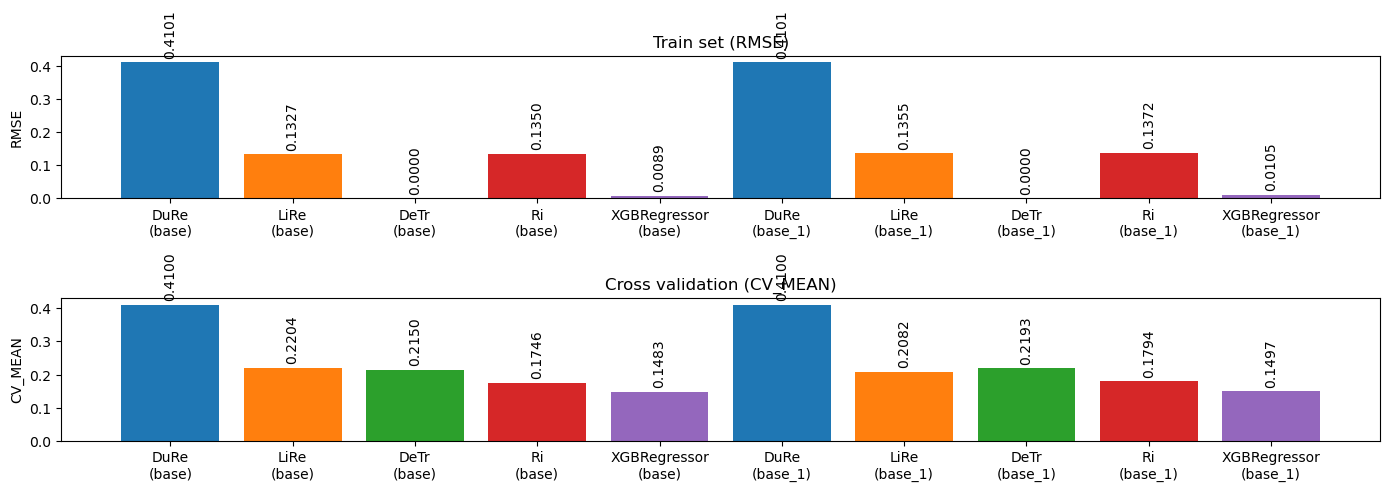

In [81]:

# Before starting the analysis, let's setup a baseline performance
# Testing some simple models
run_label="base"
df_ready = nans_simple_fix(df_data)

# Split in train and test datasets
X, Y, X_test, Y_test = split_data(df_ready)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

run_label="base_1"
df_ready1 = nans_general_fix(df_data)

X, Y, X_test, Y_test = split_data(df_ready1)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

show_global_scores()
plot_scores()


In [82]:
g_df_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            10 non-null     object 
 1   model           10 non-null     object 
 2   run_label       10 non-null     object 
 3   TRN_RMSE        10 non-null     float64
 4   TRN_NRMSE       10 non-null     float64
 5   TRN_PERC_NRMSE  10 non-null     float64
 6   TST_RMSE        10 non-null     int64  
 7   TST_NRMSE       10 non-null     int64  
 8   TST_PERC_NRMSE  10 non-null     int64  
 9   CV_MEAN         10 non-null     float64
 10  CV_01           10 non-null     float64
 11  CV_02           10 non-null     float64
 12  CV_03           10 non-null     float64
 13  CV_04           10 non-null     float64
 14  CV_05           10 non-null     float64
dtypes: float64(9), int64(3), object(3)
memory usage: 1.3+ KB


# Testing models and techniques

Train dataset shape: (1168, 198)
Test dataset shape: (292, 198)
Using log1p transformation for RMSE
Model: DummyRegressor,  Params: {'constant': None, 'quantile': None, 'strategy': 'mean'}
Using log1p transformation for RMSE


/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Model: LinearRegression,  Params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Using log1p transformation for RMSE
Model: DecisionTreeRegressor,  Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Using log1p transformation for RMSE
Model: Ridge,  Params: {'alpha': 0.7, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Using log1p transformation for RMSE
Model: XGBRegressor,  Params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': Fals

/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Model: LinearRegression,  Params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Using log1p transformation for RMSE
Model: DecisionTreeRegressor,  Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Using log1p transformation for RMSE
Model: Ridge,  Params: {'alpha': 0.7, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Using log1p transformation for RMSE
Model: XGBRegressor,  Params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': Fals

,date,model,run_label,TRN_RMSE,TRN_NRMSE,TRN_PERC_NRMSE,TST_RMSE,TST_NRMSE,TST_PERC_NRMSE,CV_MEAN,CV_01,CV_02,CV_03,CV_04,CV_05
0,2026-01-21 18:30,DummyRegressor,base,0.41007,0.0,0.00023,0,0,0,0.40998,0.39537,0.42277,0.44261,0.40203,0.38711
1,2026-01-21 18:30,LinearRegression,base,0.13266,0.0,0.00007,0,0,0,0.22040,0.25980,0.30137,0.20307,0.16455,0.17319
2,2026-01-21 18:30,DecisionTreeRegressor,base,0.00000,0.0,0.00000,0,0,0,0.21504,0.18262,0.23337,0.22245,0.23235,0.20439
3,2026-01-21 18:30,Ridge,base,0.13498,0.0,0.00007,0,0,0,0.17464,0.16171,0.20310,0.17664,0.15306,0.17867
4,2026-01-21 18:30,XGBRegressor,base,0.00885,0.0,0.00000,0,0,0,0.14831,0.12556,0.18164,0.16764,0.15108,0.11566
5,2026-01-21 18:30,DummyRegressor,base_1,0.41007,0.0,0.00023,0,0,0,0.40998,0.39537,0.42277,0.44261,0.40203,0.38711
6,2026-01-21 18:30,LinearRegression,base_1,0.13546,0.0,0.00007,0,0,0,0.20824,0.16359,0.33562,0.20590,0.16498,0.17110
7,2026-01-21 18:30,DecisionTreeRegressor,base_1,0.00000,0.0,0.00000,0,0,0,0.21927,0.23408,0.22593,0.22646,0.21966,0.19023
8,2026-01-21 18:30,Ridge,base_1,0.13717,0.0,0.00008,0,0,0,0.17943,0.15450,0.20915,0.19307,0.15623,0.18421
9,2026-01-21 18:30,XGBRegressor,base_1,0.01051,0.0,0.00001,0,0,0,0.14967,0.12294,0.18475,0.16646,0.15403,0.12019


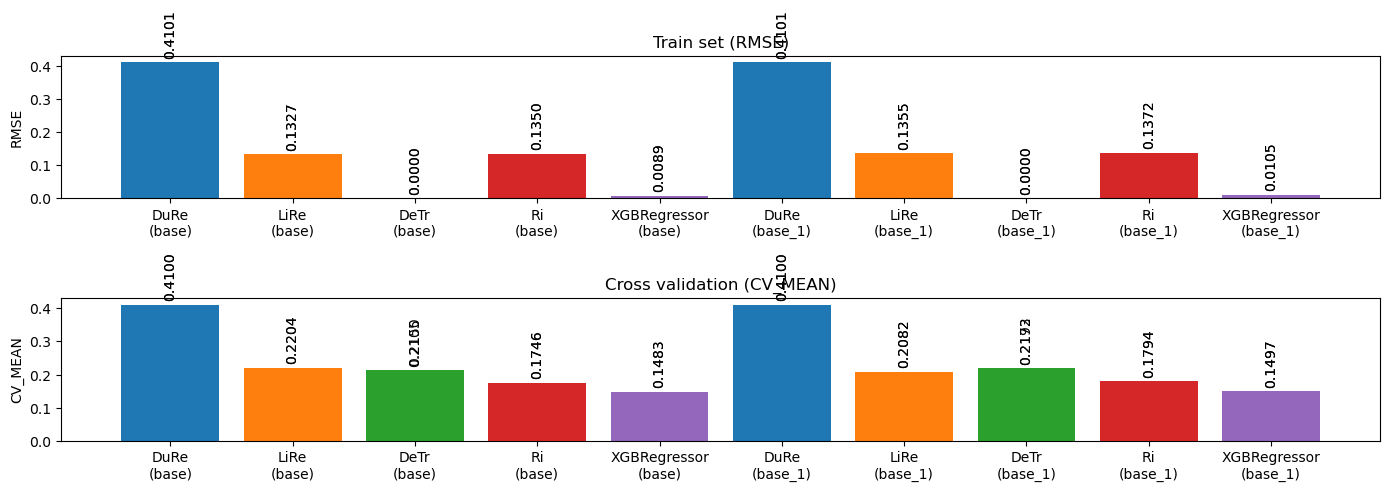

In [83]:

# Before starting the analysis, let's setup a baseline performance
# Testing some simple models
run_label="base"
df_ready = nans_simple_fix(df_data)

# Split in train and test datasets
X, Y, X_test, Y_test = split_data(df_ready)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

run_label="base_1"
df_ready1 = nans_general_fix(df_data)

X, Y, X_test, Y_test = split_data(df_ready1)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

show_global_scores()
plot_scores()


# Exploratory Data Analysis (EDA)

## Spotting outliners

['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea']


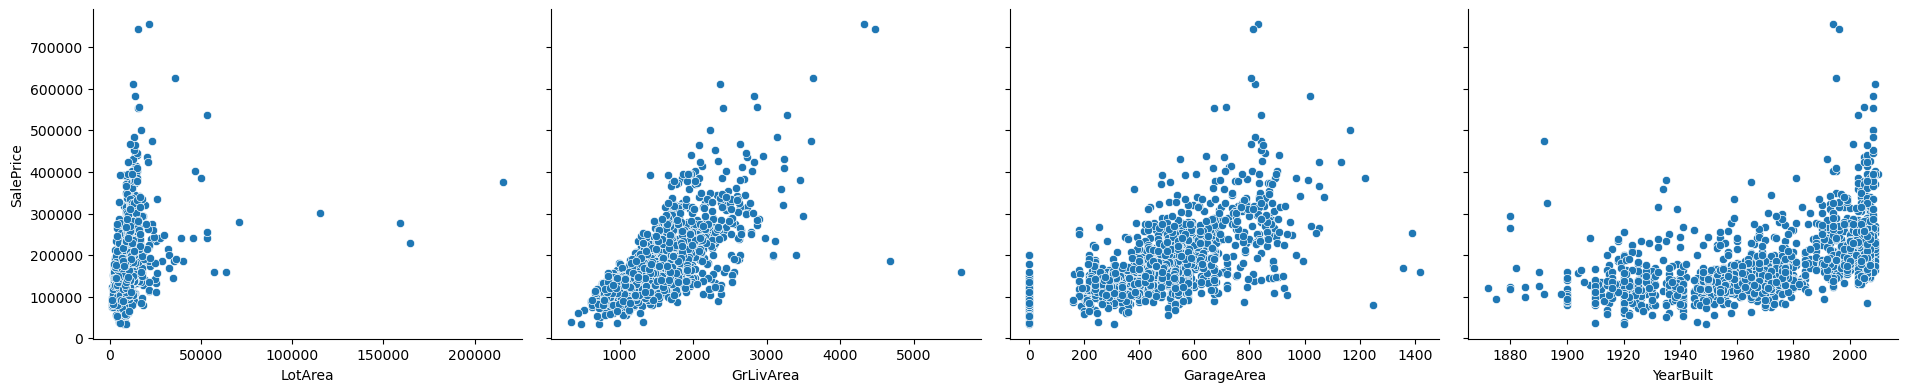

In [84]:
# Trying to spot Outliners

# Getting numeric cols
num_cols, _, _ = extract_categorical_columns(df_data, k=g_max_ohe_cardinality)
num_cols = [col for col in num_cols if col not in g_ord_cols]

to_remove = ["Id", "SalePrice", "MSSubClass", "MoSold", "YrSold", "MiscVal"]
for col in to_remove:
    if col in num_cols:
        num_cols.remove(col)

print(num_cols)
df_data[num_cols].describe()


#sns.pairplot(df_data[key_num], diag_kind='kde')


key_num = ["LotArea", "GrLivArea", "GarageArea", "YearBuilt"]

show_pair_grid(df_ready, key_num)


## Probplot

((array([-3.24209521, -2.98025416, -2.83435097, ...,  2.83435097,
          2.98025416,  3.24209521]),
  array([10.46027076, 10.47197813, 10.54273278, ..., 13.32392858,
         13.34550853, 13.53447435])),
 (np.float64(0.4008552844528393),
  np.float64(12.02336170160076),
  np.float64(0.9951745651828708)))

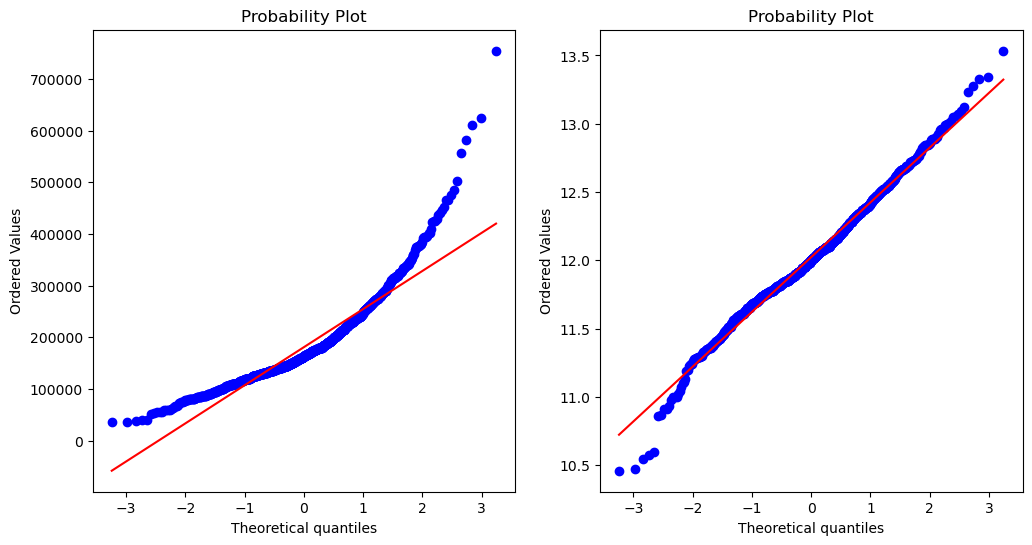

In [85]:
Y_log1p = np.log1p(Y)
_, axes = plt.subplots(1, 2, figsize=(12, 6))
stats.probplot(Y, dist="norm", plot=axes[0])
stats.probplot(Y_log1p, dist="norm", plot=axes[1])

## Columns Type Split - g_col_split_dic

In [86]:

key_num2 = ["LotFrontage", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "WoodDeckSF", "OpenPorchSF", "LowQualFinSF", "3SsnPorch", "ScreenPorch", "EnclosedPorch"]
feat_sec_sf = ["LotFrontage","MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GarageArea", "WoodDeckSF", "OpenPorchSF", "PoolArea"]
feat_year = ["YearBuilt", "GarageYrBlt", "YearRemodAdd" ]
feat_count = ["BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageCars"]
df_ready[key_num2].describe()

g_col_split_dic = {
    "key_num": key_num,
    "key_num2": key_num2,
    "feat_sec_sf": feat_sec_sf,
    "feat_year": feat_year,
    "feat_count": feat_count
}



In [87]:
# The features below have more than 75% = 0. Let's check what happen when removing them
feat_rmv = ["LowQualFinSF", "3SsnPorch", "ScreenPorch", "EnclosedPorch"]

df_rmv = remove_unused_features(df_ready, feat_rmv)



Cols to remove: ['LowQualFinSF', '3SsnPorch', 'ScreenPorch', 'EnclosedPorch']


## Removing outliers

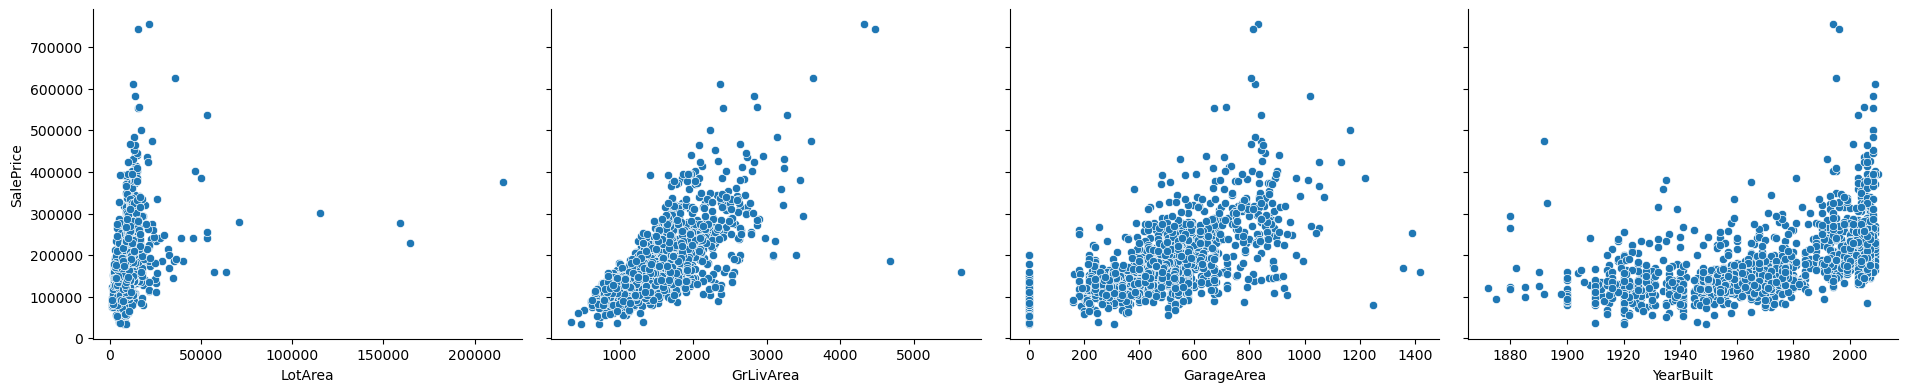

In [88]:
# After some test 1.5 is the best value
#df_rem = remove_outliers(df_ready, key_num, 1.5)
df_rem = clip_outliers(df_ready)
df_rem = df_ready.copy()
show_pair_grid(df_rem, key_num)



/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Train dataset shape: (1168, 198)
Test dataset shape: (292, 198)
Using log1p transformation for RMSE
Model: DummyRegressor,  Params: {'constant': None, 'quantile': None, 'strategy': 'mean'}
Using log1p transformation for RMSE
Model: LinearRegression,  Params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Using log1p transformation for RMSE
Model: DecisionTreeRegressor,  Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Using log1p transformation for RMSE
Model: Ridge,  Params: {'alpha': 0.7, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Using log1p transformation for RMSE
Model: XGBRegressor,  Params: {'objective': 're

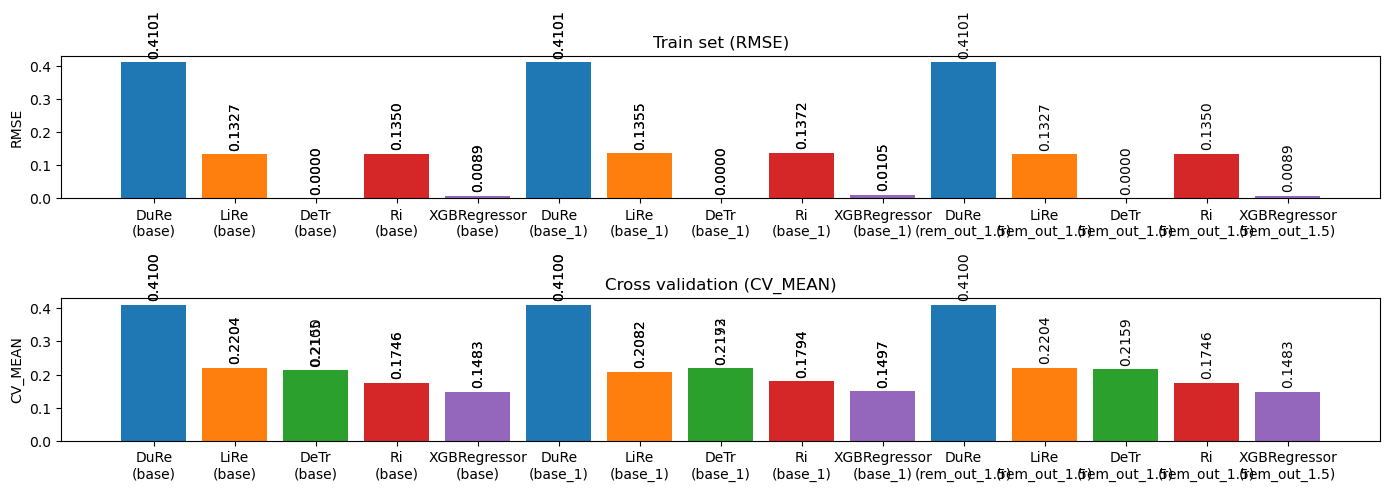

In [89]:
run_label = "rem_out_1.5"
X, Y, X_test, Y_test = split_data(df_rem)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

#show_global_scores()
plot_scores()

In [90]:

feat_rmv = ["LowQualFinSF", "3SsnPorch", "ScreenPorch", "EnclosedPorch"]

df_ready[feat_rmv].describe()

,LowQualFinSF,3SsnPorch,ScreenPorch,EnclosedPorch
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,5.844521,3.409589,15.060959,21.954110
std,48.623081,29.317331,55.757415,61.119149
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,572.000000,508.000000,480.000000,552.000000


## Log1p

## Count features proc

Current Label: 1
LotArea 12.207687851233496
LotArea q1 7553.5 q3:  11601.5
LotArea iqr 4048.0 lower:  1481.5 upper:  17673.5
Outliers up:  67
Outliers low:  2
69 Outliners Rows removed for col LotArea
New shape (1391, 81)
69 Outliners Rows removed in total
Using log1p transformation for RMSE
Model: DummyRegressor,  Params: {'constant': None, 'quantile': None, 'strategy': 'mean'}
Using log1p transformation for RMSE


/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 19, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Model: LinearRegression,  Params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Using log1p transformation for RMSE
Model: DecisionTreeRegressor,  Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Using log1p transformation for RMSE
Model: Ridge,  Params: {'alpha': 0.7, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Using log1p transformation for RMSE
Model: XGBRegressor,  Params: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': Fals

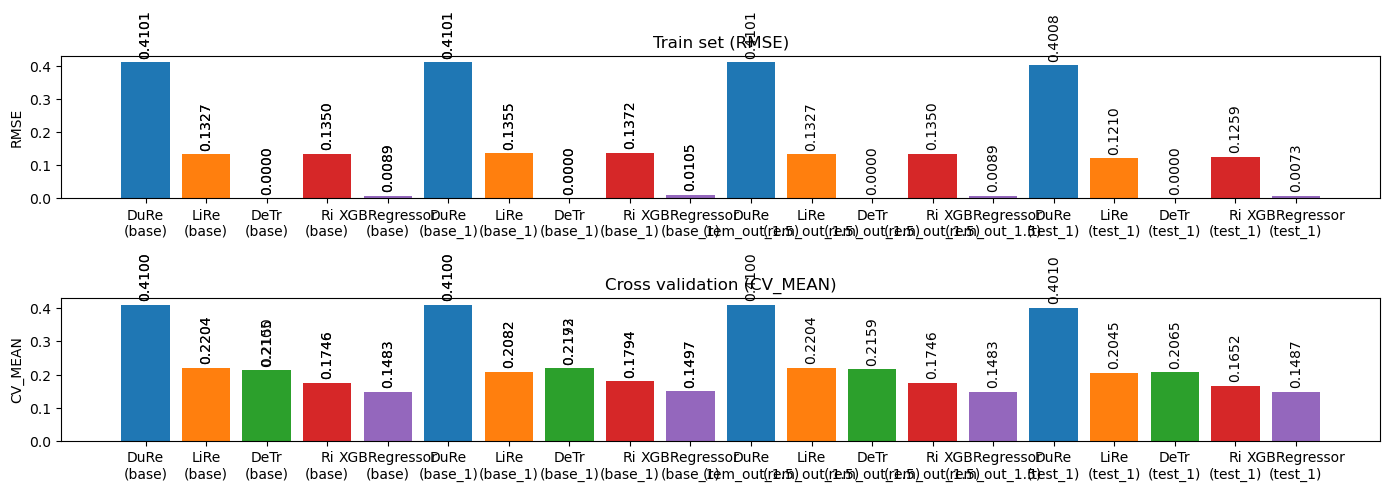

In [91]:
key_num = g_col_split_dic["key_num"]
feat_count = g_col_split_dic["feat_count"]

g_lbl_cnt+=1
print("Current Label:", g_lbl_cnt)
run_label = "test_" + str(g_lbl_cnt)


outl = ["LotFrontage", "BsmtFinSF1", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GarageArea", "OpenPorchSF", "LotArea", "GrLivArea"]


outl_all = np.unique(np.concatenate((key_num, outl)))
df_rmv = remove_outliers(df_ready, outl_all, 1.5)

#feat_count = ["BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageCars"]
# let's try creating features
df_rmv["HouseAge"] = datetime.now().year - df_rmv["YearBuilt"]
df_rmv["TotalSF"] = df_rmv["TotalBsmtSF"] + df_rmv["1stFlrSF"] + df_rmv["2ndFlrSF"] 
df_rmv["TotalBath"] = df_rmv["FullBath"] + df_rmv["HalfBath"] * 0.5
df_rmv["TotalSFSqrt"] = np.sqrt(df_rmv["TotalSF"]) 
df_rmv["GrLivAreaSqrt"] = np.sqrt(df_rmv["GrLivArea"]) 

df_rmv = log1p_transform(df_rmv, columns=key_num)



# For each of this full 0 columns, try to add a binary yes/no column
# BsmtFinSF2, PoolArea, WoodDeckSF are mostly 0 (75%). We can add a 1/0 feature and normalize the value
# MasVnrAre, can try the same (50%)
#zeros_cols = ["LowQualFinSF", "3SsnPorch", "ScreenPorch", "EnclosedPorch"]
bin_cols = ["3SsnPorch", "LowQualFinSF", "ScreenPorch", "EnclosedPorch", "PoolArea", "BsmtFinSF2", "MasVnrArea", "2ndFlrSF", "TotalBsmtSF", "Fireplaces"]

for col in bin_cols:
     df_rmv[col + "_bin"] = df_rmv[col].apply(lambda x: 1 if x > 0 else 0)
    
#rem_out_02 = ["LotFrontage", "BsmtFinSF1", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GarageArea", "OpenPorchSF"]
zcols = ["3SsnPorch", "ScreenPorch", "EnclosedPorch", "PoolArea", "BsmtFinSF2", "WoodDeckSF", "BsmtFinSF1", "GarageArea", "HouseAge", "MiscVal"]
std1_cols = ["3SsnPorch", "ScreenPorch", "EnclosedPorch", "PoolArea", \
             "BsmtFinSF2", "WoodDeckSF", "GarageArea", "LotFrontage", \
             "1stFlrSF", "2ndFlrSF", "OpenPorchSF", \
             "TotalBsmtSF", "HouseAge", "GrLivAreaSqrt", "TotalSFSqrt", "GrLivArea", "TotalSF",
            "YearRemodAdd", "BsmtUnfSF", "GarageYrBlt",  "MiscVal", "YrSold", "TotalSFSqrt", "GrLivAreaSqrt"]


#wcols =  ["YearRemodAdd", "BsmtUnfSF", "GarageYrBlt",  "MiscVal", "YrSold", "TotalSF", "TotalSFSqrt", "GrLivAreaSqrt"]

# Log1p and stdnorm
# LotFrontage no
# TotalBsmtSF no no
# 1stFlrSF no
# 2ndFlrSF no
# OpenPorchSF no

# Transforming PoolArea increases performance notably
# Binary column for PoolArea helps when also log1p transform
# Binary column for BsmtFinSF2 helps when also log1p transform
# For MasVnrArea, creating a binary column only works. No log1p transformation

# WoodDeckSF not help when both
df_rmv = log1p_transform(df_rmv, columns=zcols)
#df_rmv = df_rmv.drop(["MiscVal"], axis=1) # Removing this column increases costs
# df_rmv = df_rmv.drop(["TotalSF", "GrLivArea"], axis=1) # Removing this column increases costs

X, Y, X_test, Y_test = split_data(df_rmv)

X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 
std_cols = np.unique(np.concatenate((bin_cols, std1_cols)))

X, X_test = std_norm(X, X_test, columns=std_cols)

eval_models(X, Y, X_test, Y_test, label=run_label)

# Uncomment line below to show global results (the source of the graphic)
#show_global_scores()
plot_scores()

In [92]:
g_df_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     object 
 1   model           30 non-null     object 
 2   run_label       30 non-null     object 
 3   TRN_RMSE        30 non-null     float64
 4   TRN_NRMSE       30 non-null     float64
 5   TRN_PERC_NRMSE  30 non-null     float64
 6   TST_RMSE        30 non-null     int64  
 7   TST_NRMSE       30 non-null     int64  
 8   TST_PERC_NRMSE  30 non-null     int64  
 9   CV_MEAN         30 non-null     float64
 10  CV_01           30 non-null     float64
 11  CV_02           30 non-null     float64
 12  CV_03           30 non-null     float64
 13  CV_04           30 non-null     float64
 14  CV_05           30 non-null     float64
dtypes: float64(9), int64(3), object(3)
memory usage: 3.6+ KB


In [93]:
### Show distribution

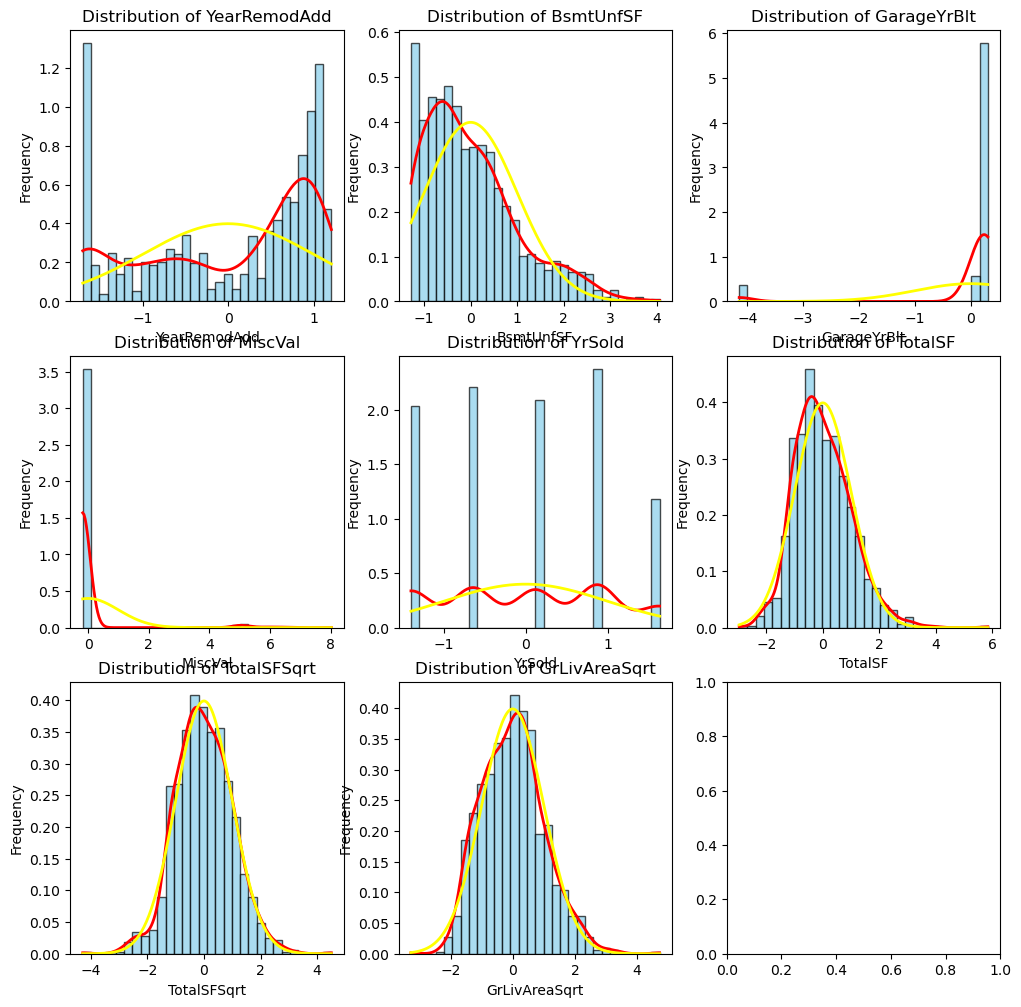

In [94]:
#X.iloc[:10, 210:220]
X
# YearRemodAdd, BsmtUnfSF, GarageYrBlt, MiscVal, YrSold, TotalSF, TotalSFSqrt, GrLivAreaSqrt
# House age is wrong. It display a year
# Neighborhood has a very hight value


wcols =  ["YearRemodAdd", "BsmtUnfSF", "GarageYrBlt",  "MiscVal", "YrSold", "TotalSF", "TotalSFSqrt", "GrLivAreaSqrt"]
X[wcols]
#X["MiscVal"].describe()
# X.loc[X["MiscVal"] == 0.0, "MiscVal"]

(X["MiscVal"] == 0.0).sum()
# 1076 0.0
X["MiscVal"]

# X["MiscVal"].head(20)
show_distribution(X, wcols)



In [95]:
#X[feat_sec_sf].describe()
f1 = ["HouseAge",]
# X[f1].describe()
X["HouseAge"].head(20)
# show_distribution(X, features=f1)

X[wcols].head()
#show_distribution(wcols)



,YearRemodAdd,BsmtUnfSF,GarageYrBlt,MiscVal,YrSold,TotalSF,TotalSFSqrt,GrLivAreaSqrt
1387,-1.698824,-1.281733,0.100244,-0.181526,-0.639957,0.953353,0.970331,1.985616
433,0.626153,0.833472,0.279719,-0.181526,0.117905,-0.003282,0.070197,0.306635
510,0.723027,-0.875139,0.177795,6.280051,0.875767,-0.217515,-0.148138,-0.208296
1282,1.110523,-0.450270,0.235404,-0.181526,0.875767,-0.609600,-0.567614,-0.976268
938,1.013649,0.835756,0.299660,-0.181526,-1.397819,1.105606,1.104103,1.004665


In [96]:

# Cols having a lot of zeros
cols = ["LowQualFinSF", "3SsnPorch", "ScreenPorch", "EnclosedPorch"]
# cols = ["LowQualFinSF"]
# cols = ["3SsnPorch"]
df_ready[df_ready[cols] > 0][cols].count()
df_ready[df_ready[cols] > 0][cols].describe()

# show_distribution(df_rmv, columns=cols)


,LowQualFinSF,3SsnPorch,ScreenPorch,EnclosedPorch
count,26.000000,24.000000,116.000000,208.000000
mean,328.192308,207.416667,189.560345,154.100962
std,167.186128,101.825049,77.952191,76.596215
min,53.000000,23.000000,40.000000,19.000000
25%,168.250000,150.750000,143.750000,104.250000
50%,377.500000,180.000000,180.000000,144.500000
75%,477.500000,239.750000,224.000000,205.000000
max,572.000000,508.000000,480.000000,552.000000


## EDA 

In [97]:
# Checking distribution for these features
feat_sec_sf = ["LotFrontage", "BsmtFinSF1", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GarageArea", "OpenPorchSF"]
#show_distribution(df_rmv, features=feat_sec_sf)
df_ready[feat_sec_sf].describe()

# BsmtFinSF2, PoolArea, WoodDeckSF are mostly 0 (75%). We can add a 1/0 feature and normalize the value
# MasVnrAre, can try the same (50%)




,LotFrontage,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GarageArea,OpenPorchSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,57.623288,443.639726,567.240411,1057.429452,1162.626712,346.992466,472.980137,46.660274
std,34.664304,456.098091,441.866955,438.705324,386.587738,436.528436,213.804841,66.256028
min,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000
25%,42.000000,0.000000,223.000000,795.750000,882.000000,0.000000,334.500000,0.000000
50%,63.000000,383.500000,477.500000,991.500000,1087.000000,0.000000,480.000000,25.000000
75%,79.000000,712.250000,808.000000,1298.250000,1391.250000,728.000000,576.000000,68.000000
max,313.000000,5644.000000,2336.000000,6110.000000,4692.000000,2065.000000,1418.000000,547.000000


In [98]:

f1 = ["BsmtUnfSF","TotalBsmtSF","1stFlrSF", "2ndFlrSF"]
df_ready[f1].describe()

,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,567.240411,1057.429452,1162.626712,346.992466
std,441.866955,438.705324,386.587738,436.528436
min,0.000000,0.000000,334.000000,0.000000
25%,223.000000,795.750000,882.000000,0.000000
50%,477.500000,991.500000,1087.000000,0.000000
75%,808.000000,1298.250000,1391.250000,728.000000
max,2336.000000,6110.000000,4692.000000,2065.000000


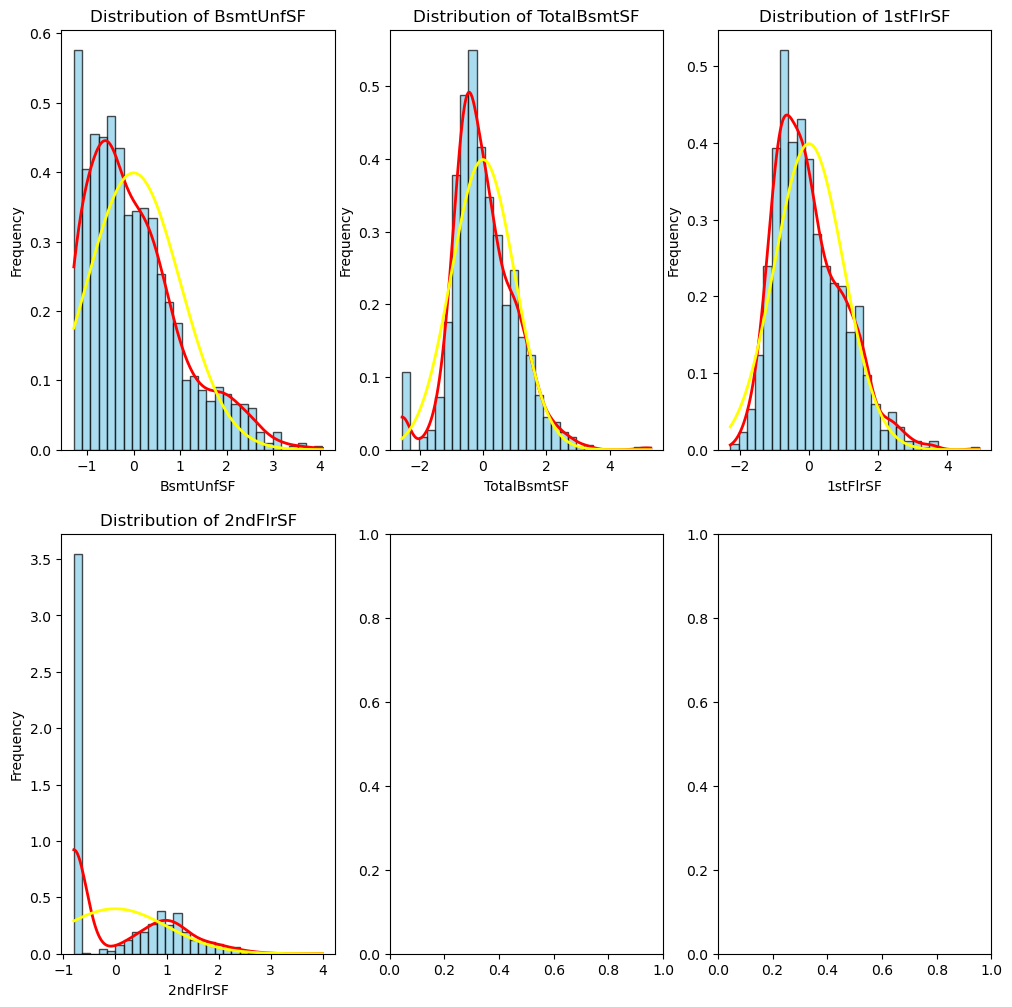

In [99]:
f1 = ["BsmtUnfSF","TotalBsmtSF","1stFlrSF", "2ndFlrSF"]
#show_distribution(df_ready, features=f1)
show_distribution(X, features=f1)


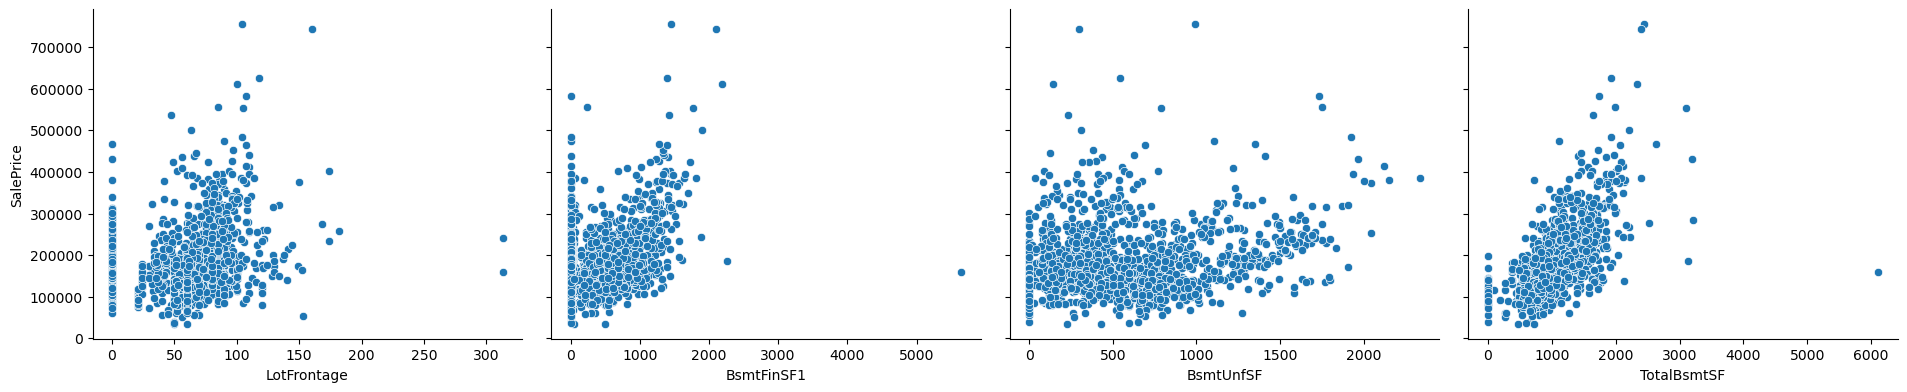

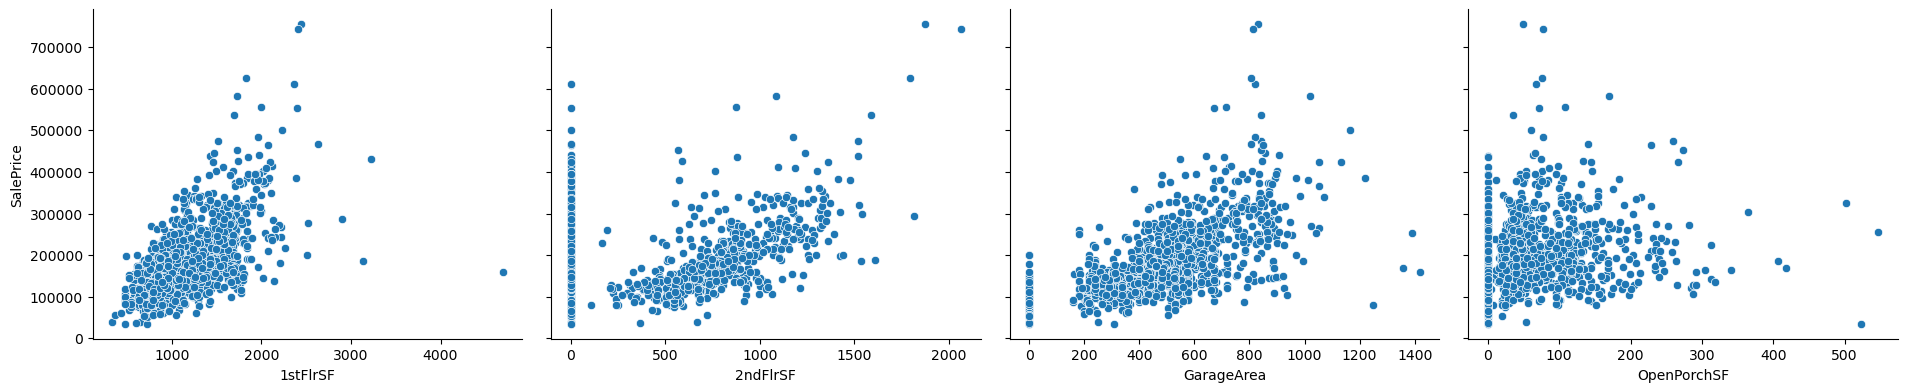

NameError: name 'remove_outliners' is not defined

In [100]:
# Checking outliers
show_pair_grid(df_ready, feat_sec_sf[:4])
show_pair_grid(df_ready, feat_sec_sf[4:])

df_out_01 = remove_outliners(df_ready, df_ready, 1.5)

print("-----------------------")
show_pair_grid(df_out_01, feat_sec_sf[:4])
show_pair_grid(df_out_01, feat_sec_sf[4:])


## Correlation inspection

In [ ]:
# Correlation between featues. It is intended to spot redundant features
plt.figure(figsize=(12, 6))
sns.heatmap(df_data.corr(numeric_only=True), cmap="coolwarm", annot=False)

In [ ]:
print_high_corr_feat(df_data, threshold=0.8)


**From the output above, we can see that some candidates for removal are:**
- GarageYrBlt
- 1sFlrSF
- TotRmsAbvGrd
- GarageCars

### Evaluate

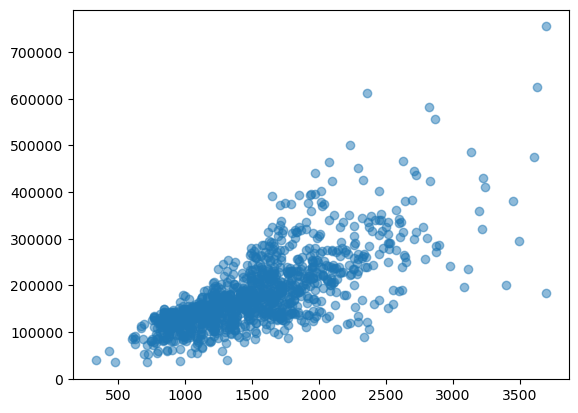

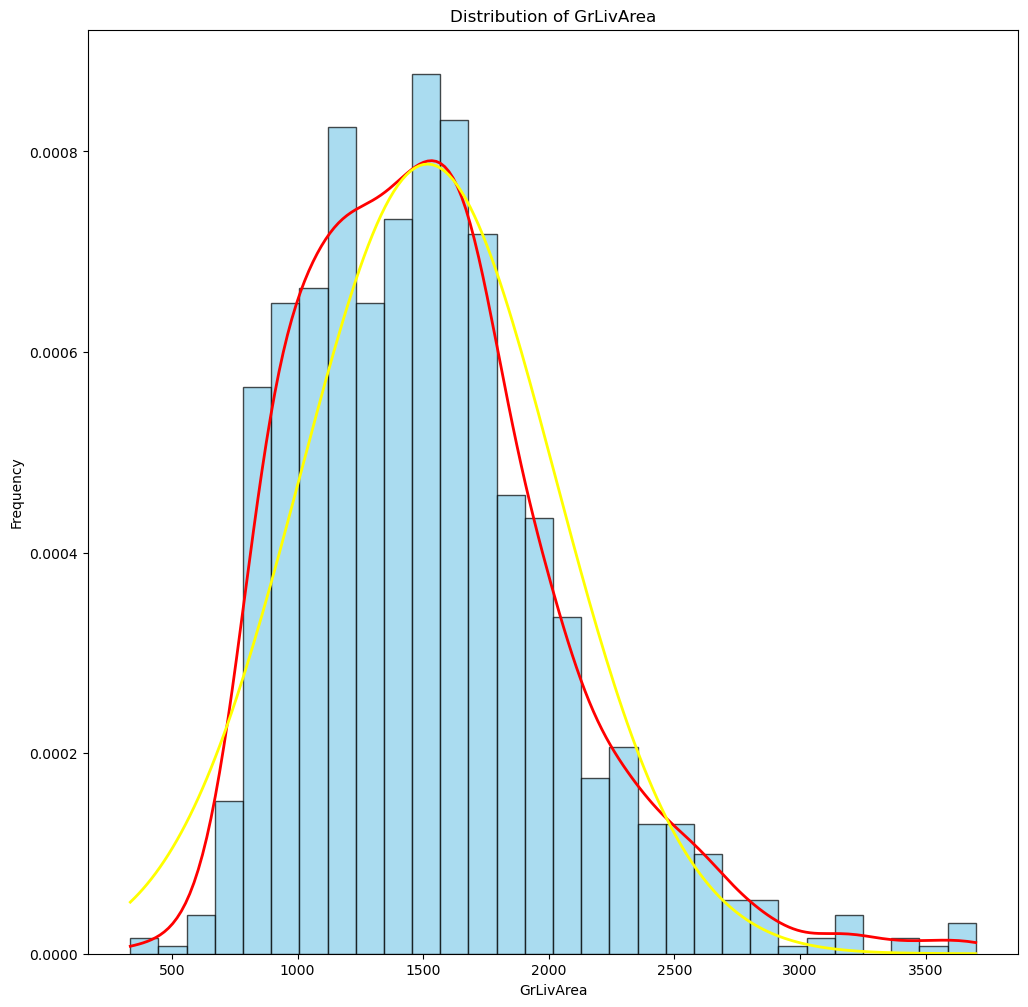

In [112]:
fig, ax = plt.subplots()
ax.scatter(X["GrLivArea"], Y, alpha=0.5)
show_distribution(X, features=["GrLivArea"])

In [113]:
#X["GrLivArea"].describe()
X.describe()


#X["GrLivArea"] = X["GrLivArea"].clip(upper=3700)

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,enc_LandSlope,enc_ExterQual,enc_ExterCond,enc_BsmtQual,enc_BsmtCond,enc_BsmtExposure,enc_BsmtFinType1,enc_BsmtFinType2,enc_HeatingQC,enc_FireplaceQu,enc_GarageQual,enc_GarageCond,enc_PoolQC,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Neighborhood,MSSubClass_30.0,MSSubClass_40.0,MSSubClass_45.0,MSSubClass_50.0,MSSubClass_60.0,MSSubClass_70.0,MSSubClass_75.0,MSSubClass_80.0,MSSubClass_85.0,MSSubClass_90.0,MSSubClass_120.0,MSSubClass_160.0,MSSubClass_180.0,MSSubClass_190.0
count,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168

/home/javi/miniconda3/envs/rl-gym/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


Train dataset shape: (1168, 195)
Test dataset shape: (292, 195)
Using log1p transformation for RMSE
Model: DummyRegressor,  Params: {'constant': None, 'quantile': None, 'strategy': 'mean'}
Using log1p transformation for RMSE
Model: LinearRegression,  Params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Using log1p transformation for RMSE
Model: DecisionTreeRegressor,  Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Using log1p transformation for RMSE
Model: Ridge,  Params: {'alpha': 0.7, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
Using log1p transformation for RMSE
Model: XGBRegressor,  Params: {'objective': 're

,date,model,run_label,TRN_RMSE,TRN_NRMSE,TRN_PERC_NRMSE,TST_RMSE,TST_NRMSE,TST_PERC_NRMSE,CV_MEAN,CV_01,CV_02,CV_03,CV_04,CV_05
0,2026-01-21 18:30,DummyRegressor,base,0.41007,0.0,0.00023,0,0,0,0.40998,0.39537,0.42277,0.44261,0.40203,0.38711
1,2026-01-21 18:30,LinearRegression,base,0.13266,0.0,0.00007,0,0,0,0.22040,0.25980,0.30137,0.20307,0.16455,0.17319
2,2026-01-21 18:30,DecisionTreeRegressor,base,0.00000,0.0,0.00000,0,0,0,0.21504,0.18262,0.23337,0.22245,0.23235,0.20439
3,2026-01-21 18:30,Ridge,base,0.13498,0.0,0.00007,0,0,0,0.17464,0.16171,0.20310,0.17664,0.15306,0.17867
4,2026-01-21 18:30,XGBRegressor,base,0.00885,0.0,0.00000,0,0,0,0.14831,0.12556,0.18164,0.16764,0.15108,0.11566
5,2026-01-21 18:30,DummyRegressor,base_1,0.41007,0.0,0.00023,0,0,0,0.40998,0.39537,0.42277,0.44261,0.40203,0.38711
6,2026-01-21 18:30,LinearRegression,base_1,0.13546,0.0,0.00007,0,0,0,0.20824,0.16359,0.33562,0.20590,0.16498,0.17110
7,2026-01-21 18:30,DecisionTreeRegressor,base_1,0.00000,0.0,0.00000,0,0,0,0.21927,0.23408,0.22593,0.22646,0.21966,0.19023
8,2026-01-21 18:30,Ridge,base_1,0.13717,0.0,0.00008,0,0,0,0.17943,0.15450,0.20915,0.19307,0.15623,0.18421
9,2026-01-21 18:30,XGBRegressor,base_1,0.01051,0.0,0.00001,0,0,0,0.14967,0.12294,0.18475,0.16646,0.15403,0.12019


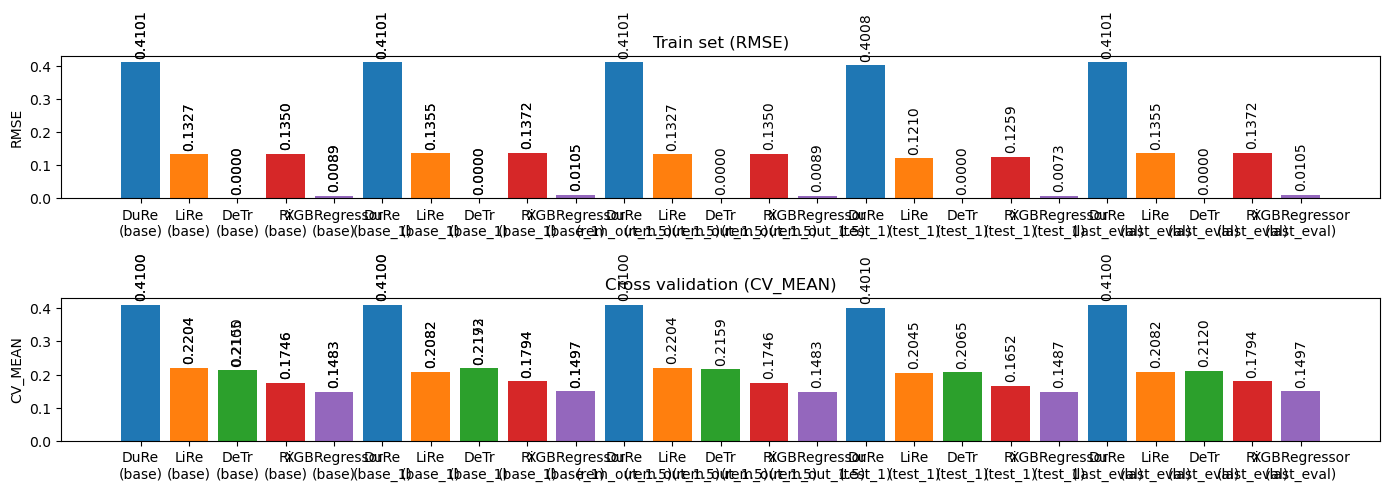

In [101]:
run_label="last_eval"
df_ready1 = nans_general_fix(df_data)

X, Y, X_test, Y_test = split_data(df_ready1)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

show_global_scores()
plot_scores()